In [1]:
# ==========================================
# CELL 1: KHAI BÁO THƯ VIỆN ĐỒ HỌA VÀ TOÁN HỌC
# ==========================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt  
import seaborn as sns           
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np

In [2]:
# ==========================================
# CELL 2: ĐỌC DỮ LIỆU TỪ ĐƯỜNG DẪN TƯƠNG ĐỐI (RELATIVE PATH)
# ==========================================
import pandas as pd

# Đường dẫn này sẽ tự động tìm vào thư mục 'data' nằm cùng chỗ với file code
file_path = "dataset/Restaurants_Train_v2.csv"

try:
    df = pd.read_csv(file_path)
    # Làm sạch cột Sentence
    df['Sentence'] = df['Sentence'].astype(str).str.lower().str.strip()
    print("✅ Đã tải và làm sạch dữ liệu thành công từ thư mục cục bộ!")
except Exception as e:
    print(f"❌ Lỗi: {e}")
    print("Vui lòng kiểm tra xem bạn đã đặt file CSV vào thư mục 'data' chưa nhé!")

✅ Đã tải và làm sạch dữ liệu thành công từ thư mục cục bộ!


In [3]:
# ==========================================
# CELL 3: HUẤN LUYỆN 4 MÔ HÌNH SVM ĐỘC LẬP TRÊN TẬP TRAIN (80%)
# ==========================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

target_aspects = ['Food', 'Service', 'Price', 'Eating Environment / Ambiance']

aspect_map = {
    'food': 'Food', 'dish': 'Food', 'pizza': 'Food', 'menu': 'Food', 'sushi': 'Food', 'steak': 'Food', 'fish': 'Food', 'taste': 'Food', 'portions': 'Food',
    'service': 'Service', 'waiter': 'Service', 'waitress': 'Service', 'staff': 'Service', 'server': 'Service',
    'price': 'Price', 'prices': 'Price', 'cost': 'Price', 'bill': 'Price', 'overpriced': 'Price',
    'ambiance': 'Eating Environment / Ambiance', 'ambience': 'Eating Environment / Ambiance', 'atmosphere': 'Eating Environment / Ambiance', 'seats': 'Eating Environment / Ambiance', 'decor': 'Eating Environment / Ambiance'
}

df['Mapped_Aspect'] = df['Aspect Term'].astype(str).str.lower().str.strip().map(aspect_map)
df['polarity'] = df['polarity'].astype(str).str.upper().str.strip()
df.loc[df['polarity'].isin(['NEUTRAL', 'CONFLICT']), 'polarity'] = 'UNKNOWN'

# CHIA TẬP DỮ LIỆU ĐÚNG CHUẨN ML: 80% Train, 20% Test
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

models_pool = {}
print("--- Đang huấn luyện mô hình trên 80% tập dữ liệu (Train Dataset) ---")

unique_train_sentences = df_train['Sentence'].unique()

for aspect in target_aspects:
    # 1. Tìm nhãn thực tế trên tập TRAIN
    aspect_rows = df_train[df_train['Mapped_Aspect'] == aspect]
    aspect_label_map = aspect_rows.drop_duplicates(subset=['Sentence']).set_index('Sentence')['polarity'].to_dict()
    
    y_train_aspect = []
    for sentence in unique_train_sentences:
        if sentence in aspect_label_map:
            y_train_aspect.append(aspect_label_map[sentence])
        else:
            y_train_aspect.append('UNKNOWN')
            
    # 2. Huấn luyện SVM đa lớp (Positive, Negative, Unknown)
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
        ('clf', SVC(kernel='linear', class_weight='balanced'))
    ])
    
    pipeline.fit(unique_train_sentences, y_train_aspect)
    models_pool[aspect] = pipeline
    print(f"✅ Đã huấn luyện bộ não cho khía cạnh: {aspect}")

--- Đang huấn luyện mô hình trên 80% tập dữ liệu (Train Dataset) ---
✅ Đã huấn luyện bộ não cho khía cạnh: Food
✅ Đã huấn luyện bộ não cho khía cạnh: Service
✅ Đã huấn luyện bộ não cho khía cạnh: Price
✅ Đã huấn luyện bộ não cho khía cạnh: Eating Environment / Ambiance


In [4]:
# ==========================================
# CELL 4: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST DATASET (20%) - CHI TIẾT
# ==========================================
from sklearn.metrics import classification_report

print("📊 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT TRÊN TẬP KIỂM THỬ (TEST DATASET)\n" + "="*65)

# Lấy các câu review từ tập TEST (20% dữ liệu)
unique_test_sentences = df_test['Sentence'].unique()
print(f"Số lượng câu test: {len(unique_test_sentences)} câu hoàn toàn mới.\n")

# Biến này lưu lại kết quả để Cell 5 vẽ biểu đồ
test_results = {}

for aspect in target_aspects:
    # 1. Xây dựng đáp án đúng (Ground Truth - y_true)
    aspect_rows = df_test[df_test['Mapped_Aspect'] == aspect]
    aspect_label_map = aspect_rows.drop_duplicates(subset=['Sentence']).set_index('Sentence')['polarity'].to_dict()
    
    y_true = []
    for sentence in unique_test_sentences:
        if sentence in aspect_label_map:
            y_true.append(aspect_label_map[sentence])
        else:
            y_true.append('UNKNOWN')
            
    # 2. Bắt mô hình dự đoán (Prediction - y_pred)
    y_pred = models_pool[aspect].predict(unique_test_sentences)
    
    # Lưu lại kết quả để Cell 5 dùng vẽ đồ thị
    test_results[aspect] = {'y_true': y_true, 'y_pred': y_pred}
    
    # 3. In ra bảng điểm chi tiết cho TỪNG khía cạnh
    print(f"📌 BẢNG ĐIỂM KHÍA CẠNH: {aspect.upper()}")
    print("-" * 65)
    print(classification_report(y_true, y_pred, labels=['POSITIVE', 'NEGATIVE', 'UNKNOWN'], zero_division=0))
    print("=" * 65 + "\n")

📊 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT TRÊN TẬP KIỂM THỬ (TEST DATASET)
Số lượng câu test: 655 câu hoàn toàn mới.

📌 BẢNG ĐIỂM KHÍA CẠNH: FOOD
-----------------------------------------------------------------
              precision    recall  f1-score   support

    POSITIVE       0.48      0.57      0.52        91
    NEGATIVE       0.18      0.17      0.18        23
     UNKNOWN       0.90      0.87      0.89       541

    accuracy                           0.81       655
   macro avg       0.52      0.54      0.53       655
weighted avg       0.82      0.81      0.81       655


📌 BẢNG ĐIỂM KHÍA CẠNH: SERVICE
-----------------------------------------------------------------
              precision    recall  f1-score   support

    POSITIVE       0.31      0.58      0.41        36
    NEGATIVE       0.33      0.27      0.30        26
     UNKNOWN       0.95      0.91      0.93       593

    accuracy                           0.86       655
   macro avg       0.53      0.59      0.54       6

📈 TRỰC QUAN HÓA KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST CHO 4 KHÍA CẠNH

👉 BÁO CÁO TRỰC QUAN KHÍA CẠNH: FOOD


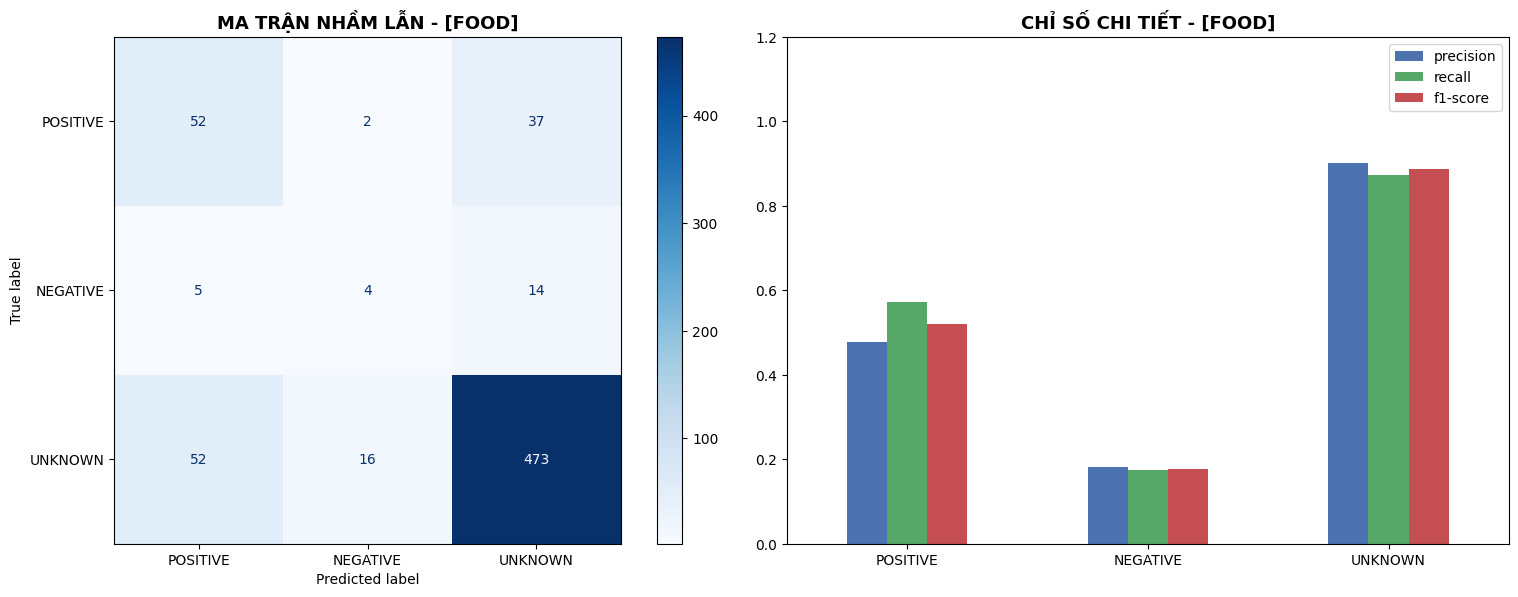

--------------------------------------------------------------------------------

👉 BÁO CÁO TRỰC QUAN KHÍA CẠNH: SERVICE


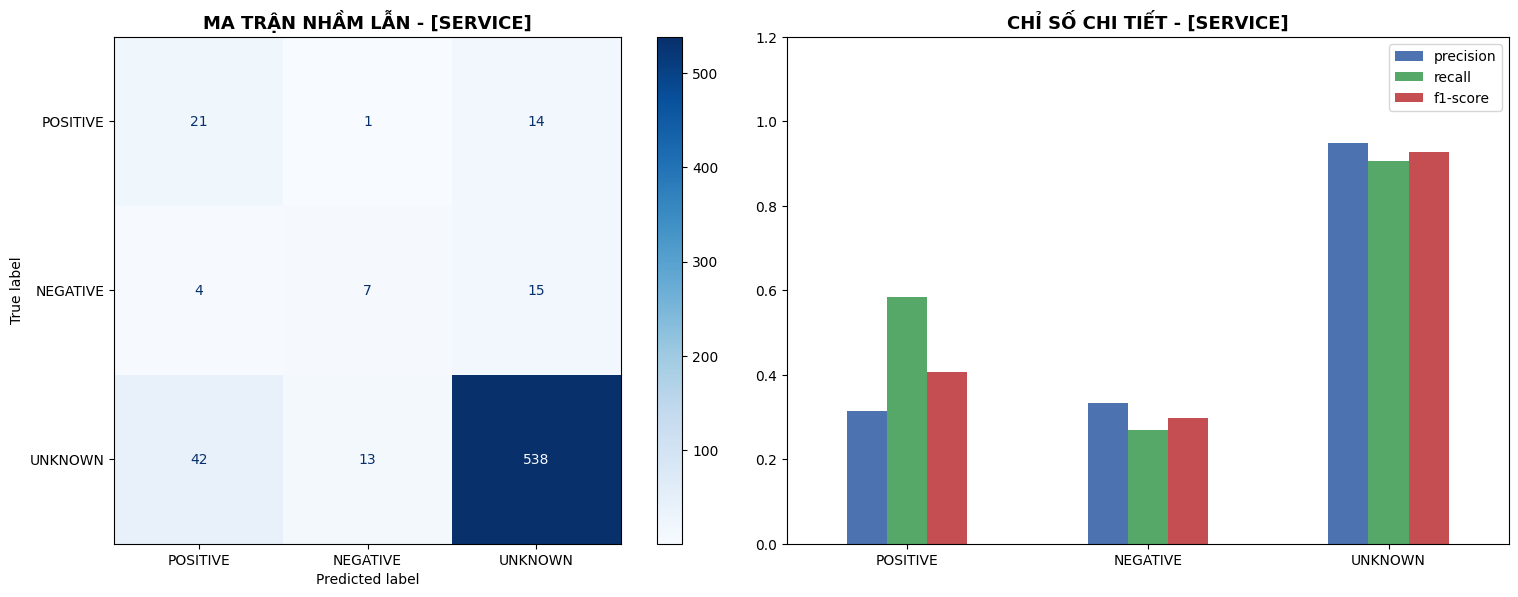

--------------------------------------------------------------------------------

👉 BÁO CÁO TRỰC QUAN KHÍA CẠNH: PRICE


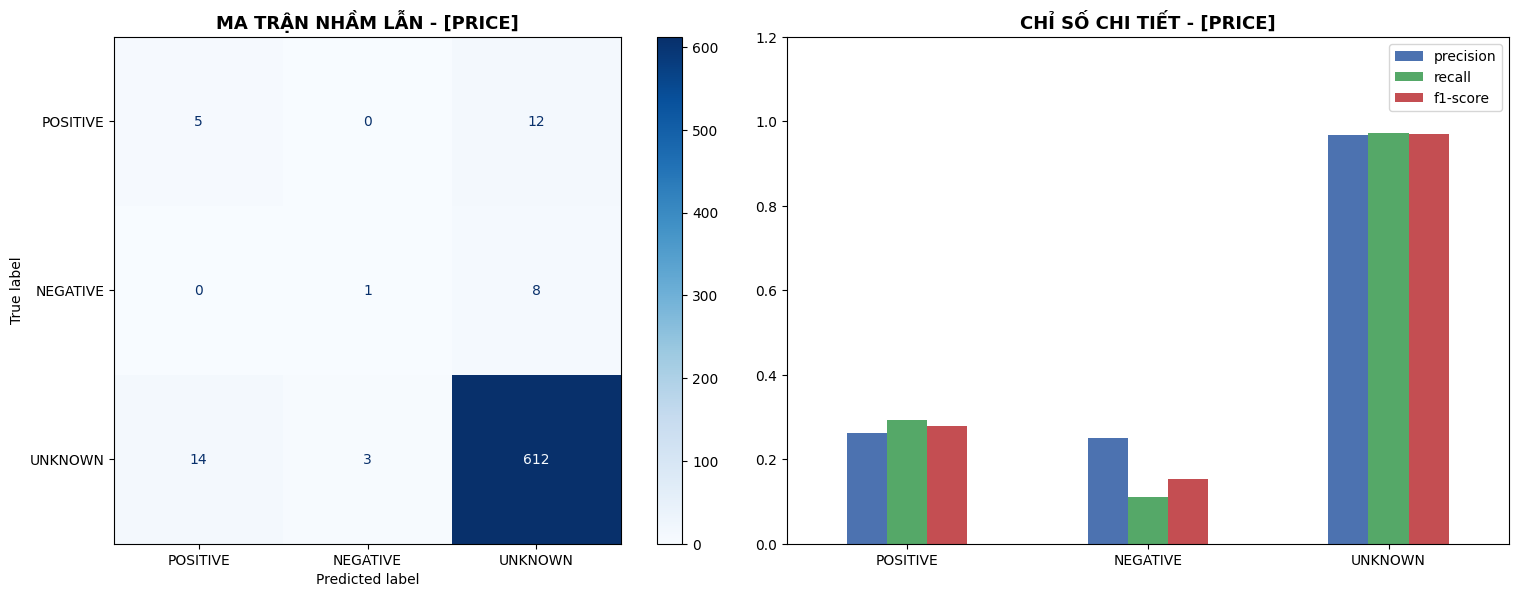

--------------------------------------------------------------------------------

👉 BÁO CÁO TRỰC QUAN KHÍA CẠNH: EATING ENVIRONMENT / AMBIANCE


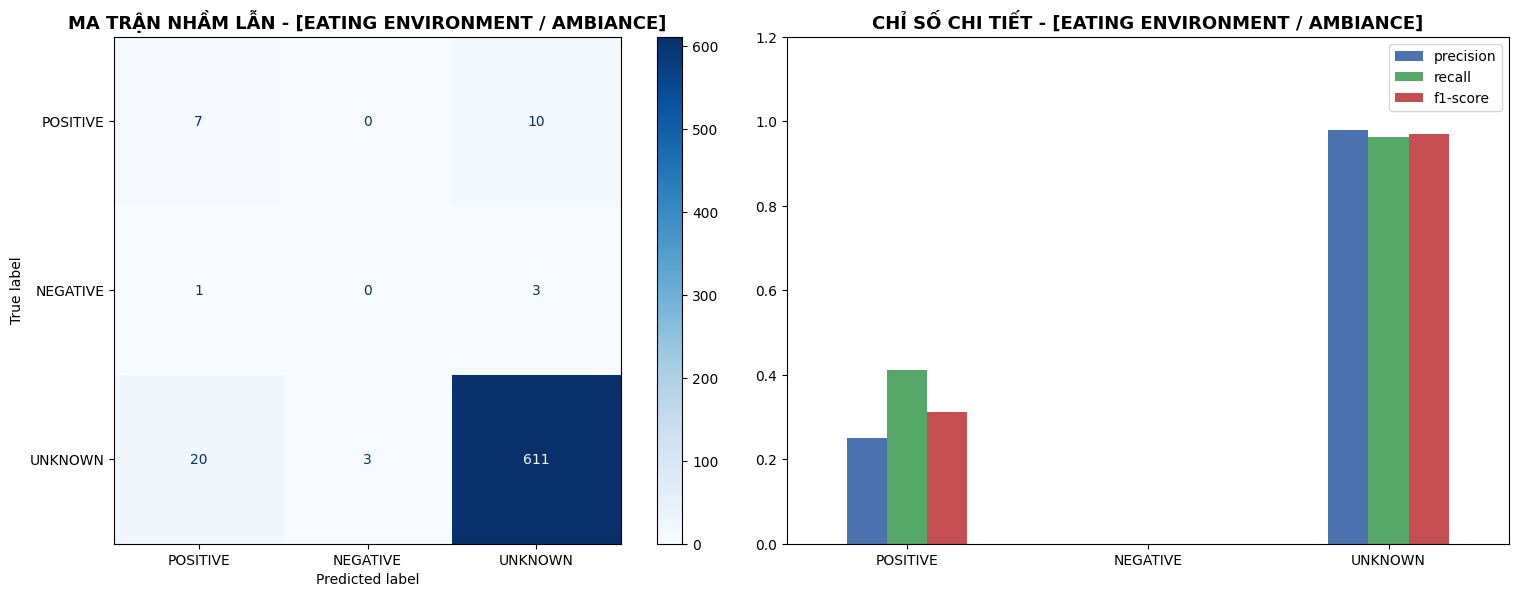

--------------------------------------------------------------------------------


In [5]:
# ==========================================
# CELL 5: TRỰC QUAN HÓA BẰNG BIỂU ĐỒ CHO CẢ 4 KHÍA CẠNH CÙNG LÚC
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd

target_labels = ['POSITIVE', 'NEGATIVE', 'UNKNOWN']
target_aspects = ['Food', 'Service', 'Price', 'Eating Environment / Ambiance']

print("📈 TRỰC QUAN HÓA KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST CHO 4 KHÍA CẠNH\n" + "="*80)

for aspect in target_aspects:
    # Lấy dữ liệu test của khía cạnh hiện tại từ biến test_results (đã lưu ở Cell 4)
    y_true = test_results[aspect]['y_true']
    y_pred = test_results[aspect]['y_pred']
    
    print(f"\n👉 BÁO CÁO TRỰC QUAN KHÍA CẠNH: {aspect.upper()}")
    
    # Tạo một khung hình (figure) chứa 2 biểu đồ nằm cạnh nhau (1 hàng, 2 cột)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- HÌNH 1 (Bên trái): MA TRẬN NHẦM LẪN LƯỚI 3x3 ---
    cm = confusion_matrix(y_true, y_pred, labels=target_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_labels)
    disp.plot(cmap=plt.cm.Blues, ax=axes[0], values_format='d')
    axes[0].set_title(f'MA TRẬN NHẦM LẪN - [{aspect.upper()}]', fontsize=13, fontweight='bold')
    axes[0].grid(False)
    
    # --- HÌNH 2 (Bên phải): BIỂU ĐỒ CHỈ SỐ F1-SCORE, PRECISION, RECALL ---
    report = classification_report(y_true, y_pred, labels=target_labels, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose().loc[target_labels, ['precision', 'recall', 'f1-score']]
    
    report_df.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#55A868', '#C44E52'])
    axes[1].set_title(f'CHỈ SỐ CHI TIẾT - [{aspect.upper()}]', fontsize=13, fontweight='bold')
    axes[1].set_ylim(0, 1.2)
    axes[1].legend(loc='upper right')
    axes[1].tick_params(axis='x', rotation=0)
    
    # Căn chỉnh khoảng cách tự động cho đẹp và hiển thị
    plt.tight_layout()
    plt.show()
    print("-" * 80)